# Modeling Place Fields with Point Process Generalized Linear Models

## Load the data

In [1]:
load('Ch9-spikes-1.mat') %Load the place field data


## Step 1

### Figure 9.1

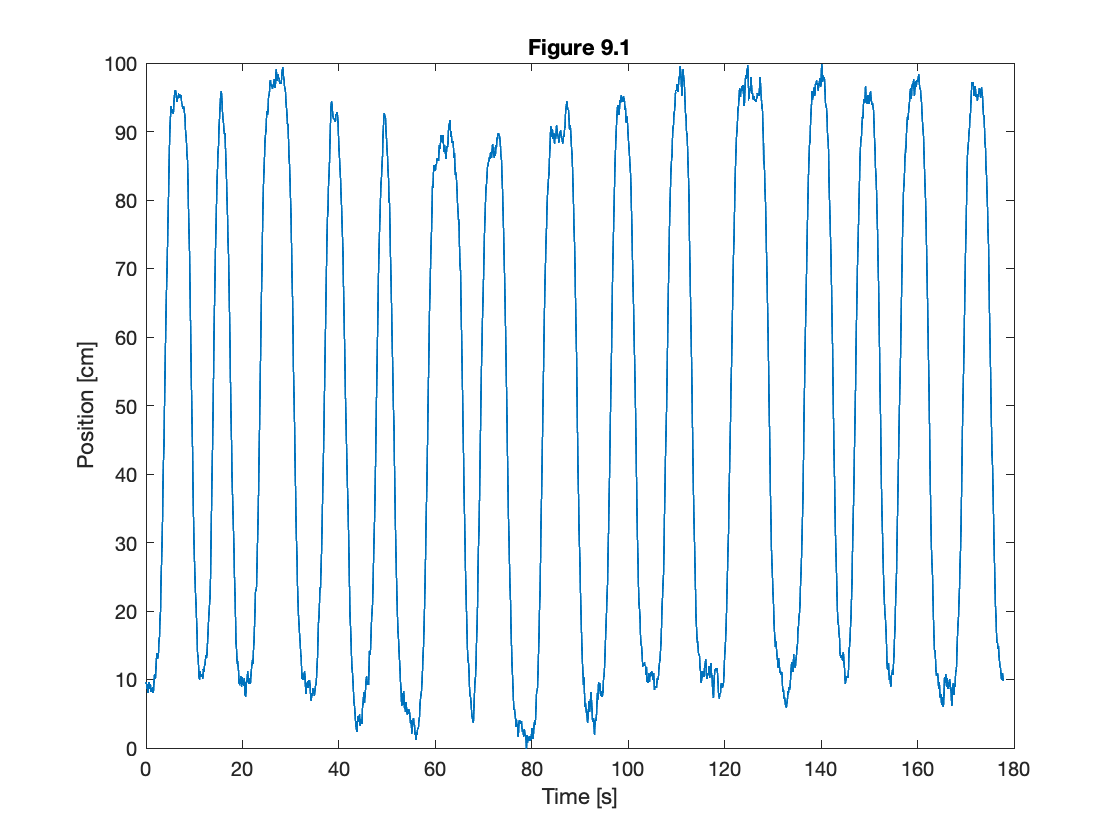

In [2]:
figure
plot(t, X, 'LineWidth', 1) %... and plot the rat's position.
ylim([0, 100])
xlabel('Time [s]'); %... with axes labelled.
ylabel('Position [cm]')
title('Figure 9.1')


### Figure 9.2

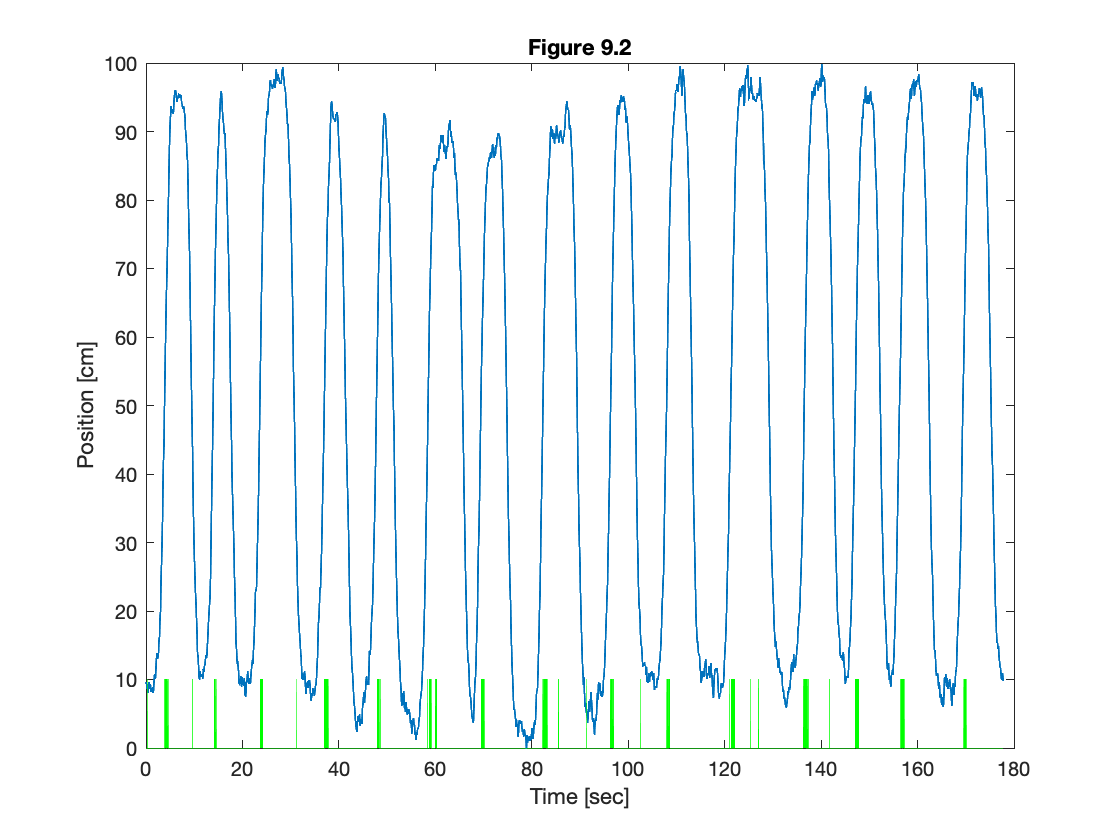

In [3]:
% Histogram spikes into bins centered at times t.
spiketrain = hist(spiketimes, t)';

figure
plot(t, X, 'LineWidth', 1) %Plot the position.
hold on %Freeze graphics window.
plot(t, 10 * spiketrain, 'g') %Plot the spikes.
ylim([0, 100])
xlabel('Time [sec]') %Label the axes.
ylabel('Position [cm]')
title('Figure 9.2')


### Figure 9.3

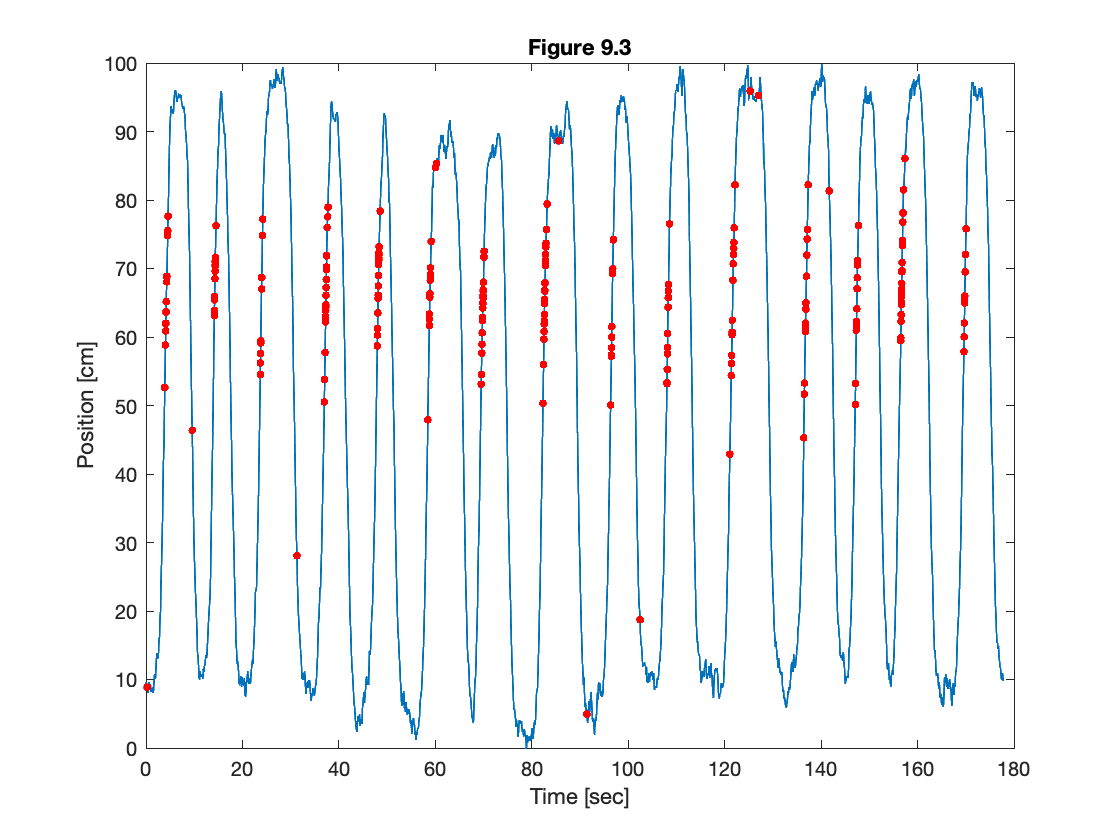

In [4]:
spikeindex = find(spiketrain); %Deterime index of each spike.

figure
plot(t, X, 'LineWidth', 1) %Plot the position.
hold on %Freeze graphics window.
plot(t(spikeindex), X(spikeindex), 'r.', 'MarkerSize', 10) %Plot spikes @ positions.
ylim([0, 100])
xlabel('Time [sec]') %Label the axes.
ylabel('Position [cm]')
title('Figure 9.3')


### Figure 9.4

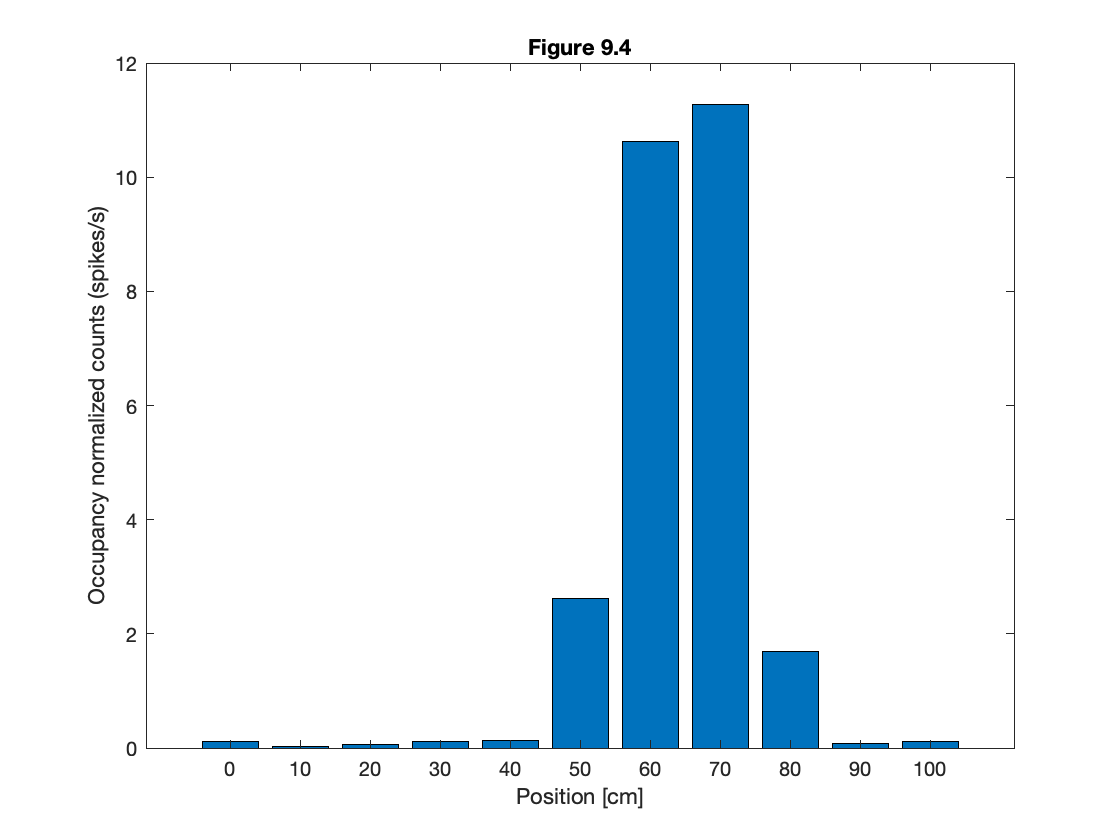

In [5]:
bins = 0:10:100; %Define spatial bins.
spikehist = hist(X(spikeindex), bins); %Histogram positions @ spikes.
occupancy = hist(X, bins) * 0.001; %Convert occupancy to seconds.

figure
bar(bins, spikehist ./ occupancy); %Plot results as bars.
xlabel('Position [cm]') %Label the axes.
ylabel('Occupancy normalized counts (spikes/s)')
title('Figure 9.4')


## Step 2

the link function may be inappropriate.

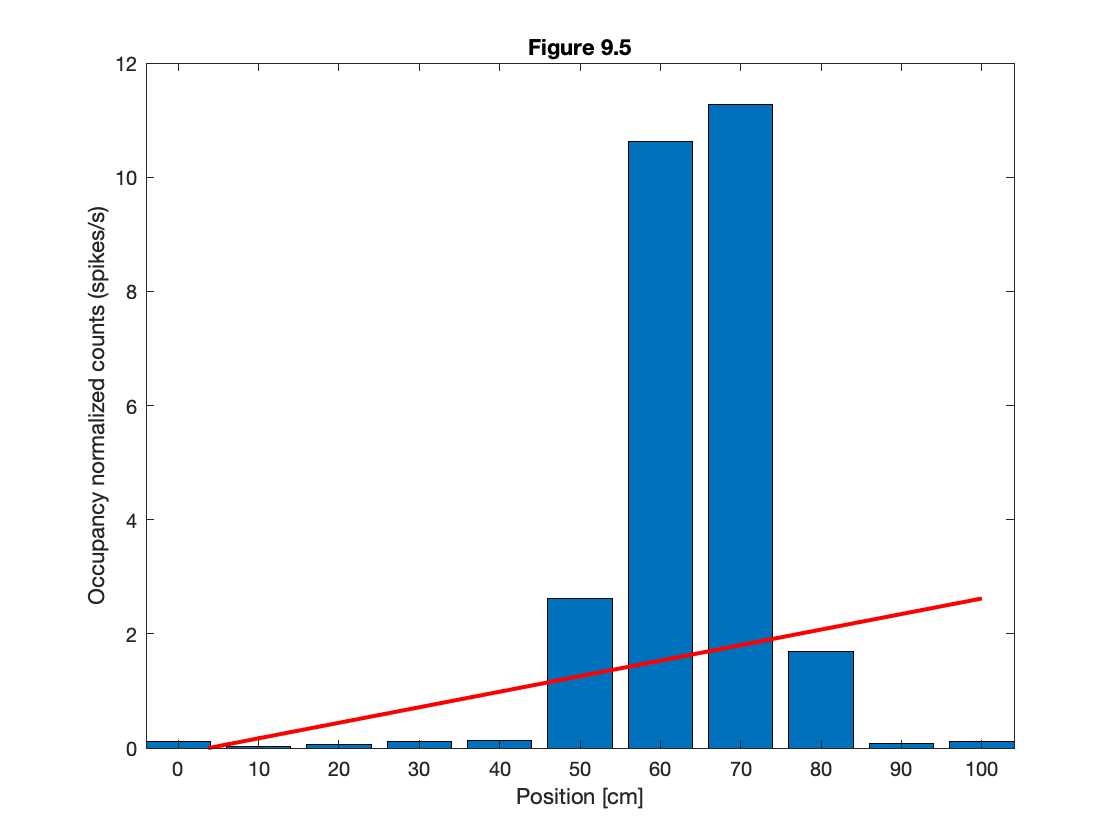

In [6]:
% Fit Model 1 to the spike train data.
b = glmfit(X, spiketrain, 'poisson', 'identity');

figure
bar(bins, spikehist ./ occupancy); %Plot occupancy norm. hist.
hold on; %Freeze graphics.
plot(bins, (b(1) + b(2) * bins) * 1000, 'r', 'LineWidth', 2); %Plot model.
xlim tight
ylim([0, 12])
xlabel('Position [cm]') %Label the axes.
ylabel('Occupancy normalized counts (spikes/s)')
title('Figure 9.5')

## Step 3

### Figure 9.5

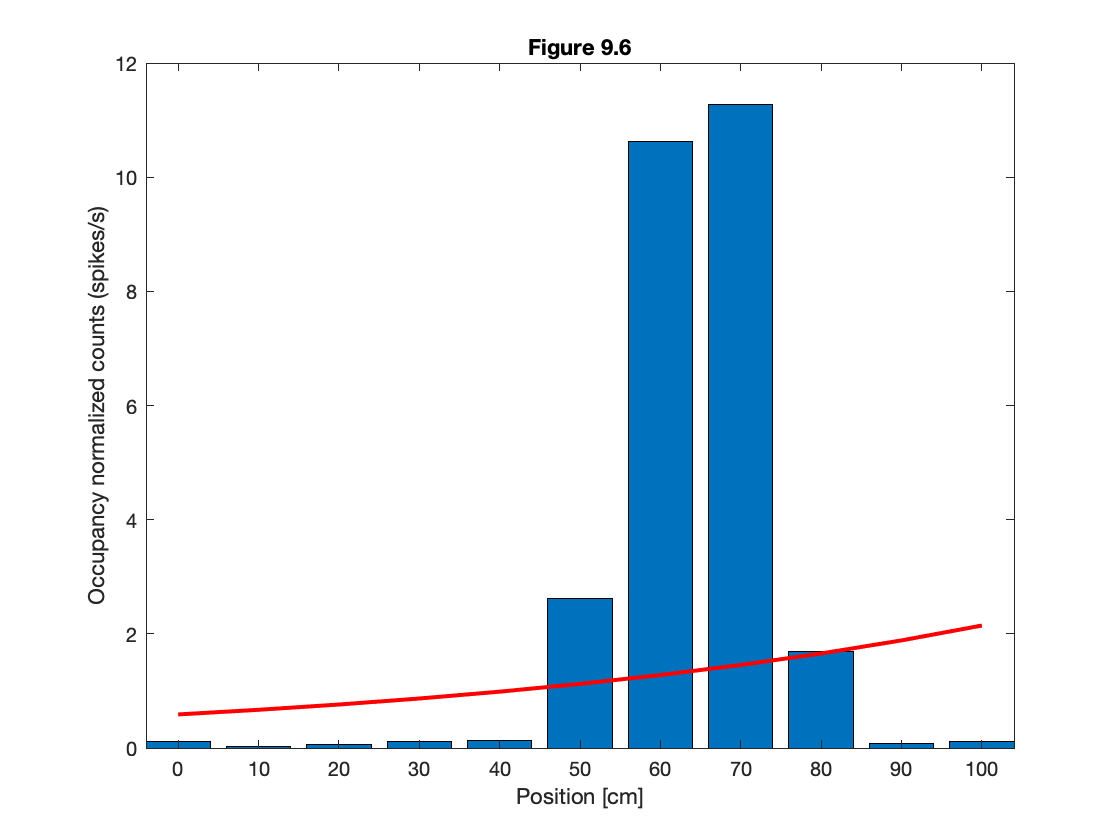

In [7]:
% Fit Model 2 to the spike train data (omitting last input).
b2 = glmfit(X, spiketrain, 'poisson');

figure
bar(bins, spikehist ./ occupancy); %Plot occupancy norm. hist.
hold on %Freeze graphics.
plot(bins, exp(b2(1) + b2(2) * bins) * 1000, 'r', 'LineWidth', 2); %Plot Model 2.
xlim tight
ylim([0, 12])
xlabel('Position [cm]') %Label the axes.
ylabel('Occupancy normalized counts (spikes/s)')
title('Figure 9.6')

### Figure 9.7

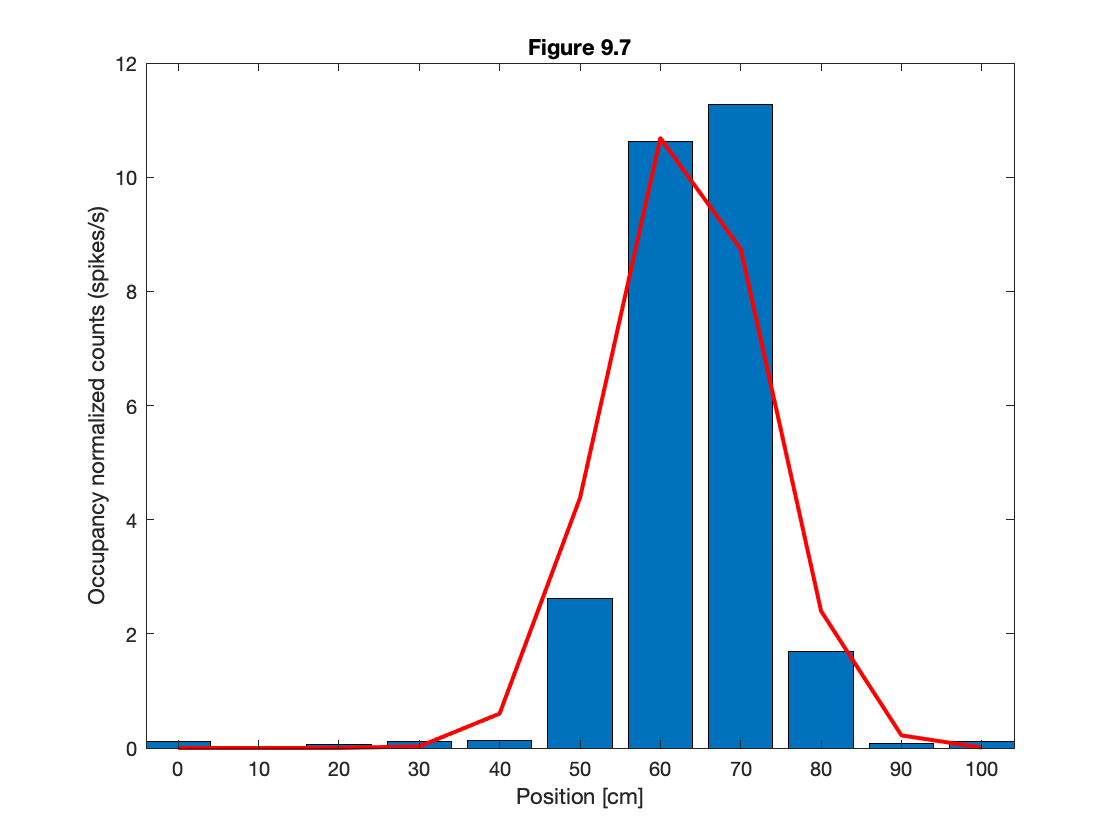

In [9]:
% Fit Model 3 to the spike train data (omitting last input).
b3 = glmfit([X X .^ 2], spiketrain, 'poisson');

figure
bar(bins, spikehist ./ occupancy); %Plot occupancy norm. hist.
hold on %Freeze graphics.
plot(bins, exp(b3(1) + b3(2) * bins + b3(3) * bins .^ 2) * 1000, 'r', ...
    'LineWidth', 2); %Model 3.
xlim tight
ylim([0, 12])
xlabel('Position [cm]') %Label the axes.
ylabel('Occupancy normalized counts (spikes/s)')
title('Figure 9.7')


In [11]:
% Compute maximum likelihood estimates of:
mu = -b3(2) / 2 / b3(3); %...place field center,
sigma = sqrt(-1 / (2 * b3(3))); %...place field size,
alpha = exp(b3(1) - b3(2) ^ 2/4 / b3(3)); %...max firing rate.
fprintf('mu = %.2f, sigma = %.2f, alpha = %.3f\n', mu, sigma, alpha);


mu = 63.16, sigma = 9.57, alpha = 0.011


## Step 4

### Method 1: Comparing AIC Values

In [13]:
lambda2 = exp(b2(1) + b2(2) * X); %Use Poisson rate function,
LL2 = sum(log(poisspdf(spiketrain, lambda2))); %..and log likelihood,
AIC2 = -2 * LL2 + 2 * 2; %...to find AIC for Model 2.

%Compute the AIC for Model 3.
AIC3 = -2 * sum(log(poisspdf(spiketrain, ...
    exp(b3(1) + b3(2) * X + b3(3) * X .^ 2)))) + 2 * 3;

dAIC = AIC2 - AIC3; %Difference in AIC between Models 1 and 2.
fprintf('Difference in AICs between Model 2 and 3: dAIC = %.4f\n', dAIC)


Difference in AICs between Model 2 and 3: dAIC = 636.0145


In [14]:
% Fit Model 2 and Model 3, and compute difference in AIC.
% Estimate AIC using deviance.
[b2, dev2, stats2] = glmfit(X, spiketrain, 'poisson');
[b3, dev3, stats3] = glmfit([X X .^ 2], spiketrain, 'poisson');
dAIC = (dev2 + 2 * 2) - (dev3 + 2 * 3);
fprintf('Difference in AICs between Model 2 and 3 (using deviance): dAIC = %.4f\n', dAIC)


Difference in AICs between Model 2 and 3 (using deviance): dAIC = 636.0145


### Method 2: Chi-Square Test for Nested Models

In [22]:
% p-value for a MLRT comparing Models 2 and 3
p = 1 - chi2cdf(dev2 - dev3, 1); % Compare Models 2 and 3, nested GLMs.
fprintf('p-value for MLRT comparing Models 2 and 3: p = %.4f\n', p)

p-value for MLRT comparing Models 2 and 3: p = 0.0000


### Method 3: Confidence Intervals for Individual Model Parameters

In [18]:
% Compute 95% CI for parameters of Model 2.
CI2 = [b2 - 2 * stats2.se b2 + 2 * stats2.se];
fprintf('95%% CI for Model 2 parameters CI2:\n')
disp(CI2)

eCI2 = exp(CI2); %Exponentiate Model 2 CIs.
fprintf('95%% CI for Model 2 parameters (exponentiated):\n')
disp(eCI2)


95% CI for Model 2 parameters CI2:
   -7.7344   -7.1433
    0.0089    0.0170
95% CI for Model 2 parameters (exponentiated):
    0.0004    0.0008
    1.0090    1.0171


In [23]:
% Compute 95% CI for parameters of Model 3.
CI3 = [b3 - 2 * stats3.se b3 + 2 * stats3.se];
fprintf('95%% CI for Model 3 parameters CI3:\n')
disp(CI3)

p_beta2 = stats3.p(3); %Significance level of Model 3 parameter.
fprintf('p-value for Model 3 parameter beta2: p_beta2 = %.4e\n', p_beta2)


95% CI for Model 3 parameters CI3:
  -29.9543  -22.6038
    0.5778    0.8024
   -0.0063   -0.0046
p-value for Model 3 parameter beta2: p_beta2 = 4.1170e-38


### Method 4: KS Test for Model Goodness-of-Fit

In [25]:
N = length(spiketimes); %Define # of spikes.
lambda3 = exp(b3(1) + b3(2) * X + b3(3) * X .^ 2); %Evaluate Model 3.
Z = zeros(N, 1); %Initialize rescaled waiting times.
Z(1) = sum(lambda3(1:spikeindex(1))); %1st rescaled waiting time.

for i = 2:N %... and the rest.
    Z(i) = sum(lambda3(spikeindex(i - 1):spikeindex(i)));
end

% Compute empirical CDF from rescaled waiting times.
[eCDF, zvals] = ecdf(Z);
mCDF = 1 - exp(-zvals); %Model CDF at z values.


### Figure 9.8

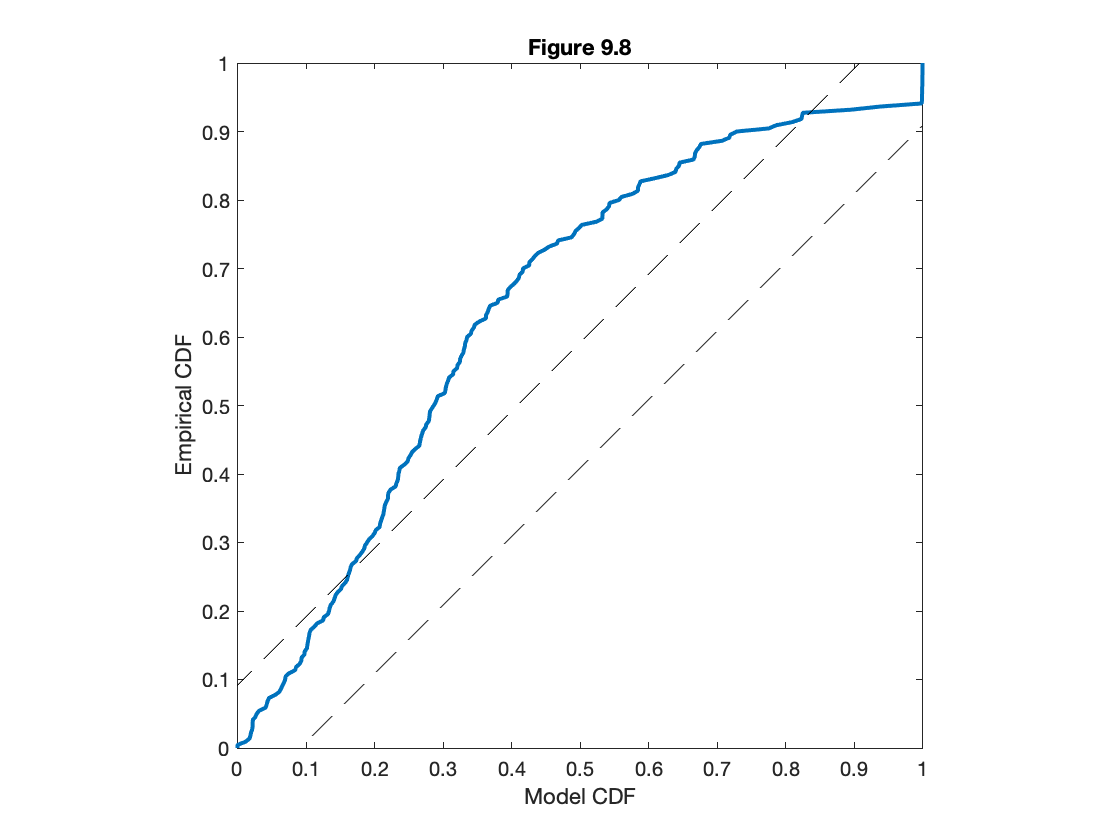

In [31]:
figure
plot(mCDF, eCDF, 'LineWidth', 2) %Create KS-plot.
hold on %Freeze graphics window.
plot([0 1], [0 1] + 1.36 / sqrt(N), 'k--') %Upper confidence bound.
plot([0 1], [0 1] - 1.36 / sqrt(N), 'k--') %Lower confidence bound.
axis([0 1 0 1]) %Set axis limits.
axis square
xlabel('Model CDF') %Label the axes.
ylabel('Empirical CDF')
title('Figure 9.8') %Title the plot.

### Figure 9.9

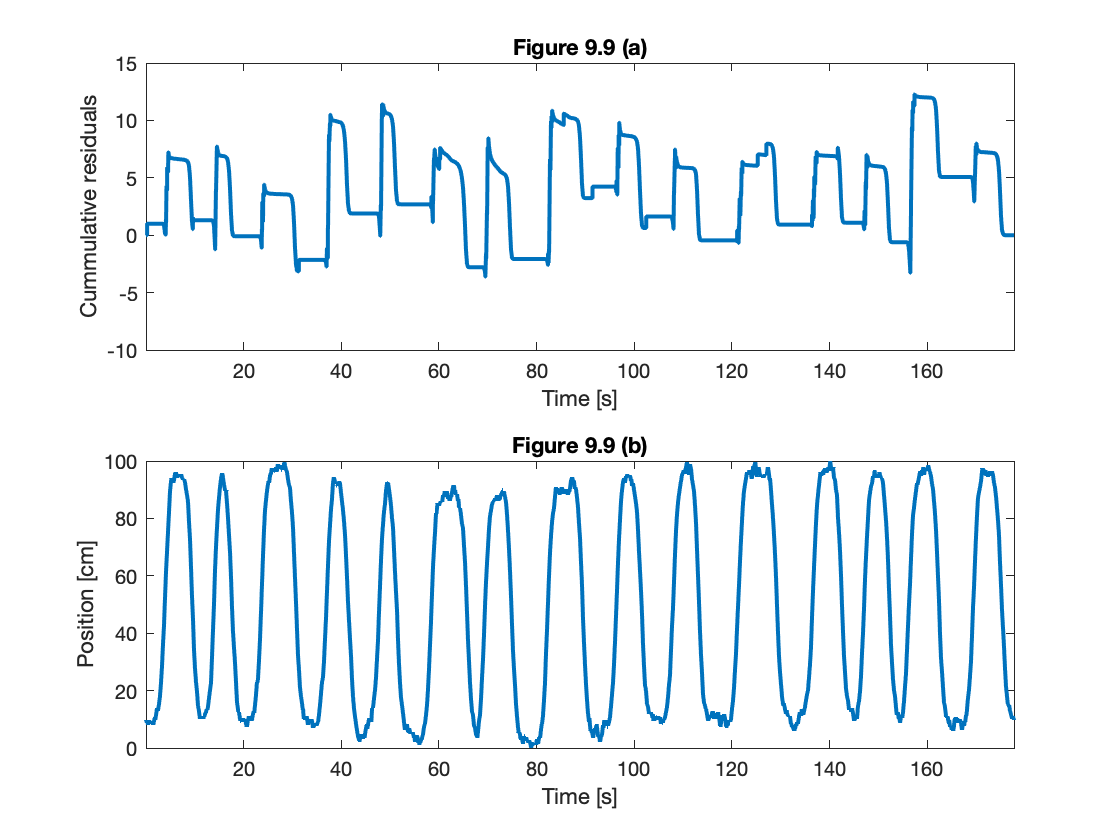

In [39]:
R = cumsum(stats3.resid); %Cumulative sum of Model 3 residuals.

figure
subplot(2, 1, 1)
plot(t, R, 'LineWidth', 2) %Plot residuals.
xlim tight
ylim([-10, 15])
xlabel('Time [s]') %Label the axes.
ylabel('Cummulative residuals')
title('Figure 9.9 (a)') %Title the plot.

subplot(2, 1, 2)
plot(t, X, 'LineWidth', 2) % Plot position.
xlim tight
ylim([0, 100])
xlabel('Time [s]') % Label the axes.
ylabel('Position [cm]')
title('Figure 9.9 (b)') % Title the plot.

## Step 3 (revisited)

In [40]:
dir = [0; diff(X) > 0];

% Fit Model 4, and return estimates and useful statistics.
[b4, dev4, stats4] = glmfit([X X .^ 2 dir], spiketrain, 'poisson');
fprintf('b4(4) = %.4f, p-value = %.4e\n', b4(4), stats4.p(4));
fprintf('exp(b4(4)) = %.4f\n', exp(b4(4)));


b4(4) = 3.2753, p-value = 9.5422e-20
exp(b4(4)) = 26.4521


## Step 4 (revisited)

In [42]:
dAIC = (dev3 + 2 * 3) - (dev4 + 2 * 4); %Difference in AIC between Models 3&4.
fprintf('Difference in AICs between Model 3 and 4: dAIC = %.4f\n', dAIC)

p = 1 - chi2cdf(dev3 - dev4, 1); %Compare Models 3 and 4, nested GLMs.
fprintf('p-value for MLRT comparing Models 3 and 4: p = %.4f\n', p)


Difference in AICs between Model 3 and 4: dAIC = 233.8806
p-value for MLRT comparing Models 3 and 4: p = 0.0000


In [43]:
% For model 4, compute 95% CI for last parameter,
CI_beta3 = [b4(4) - 2 * stats4.se(4) b4(4) + 2 * stats4.se(4)];
fprintf('95%% CI for Model 4 parameter beta3:\n')
disp(CI_beta3)

p_beta3 = stats4.p(4); %... and significance level.
fprintf('p-value for Model 4 parameter beta3: p_beta3 = %.4e\n', p_beta3)


95% CI for Model 4 parameter beta3:
    2.5550    3.9957
p-value for Model 4 parameter beta3: p_beta3 = 9.5422e-20


### Figure 9.10

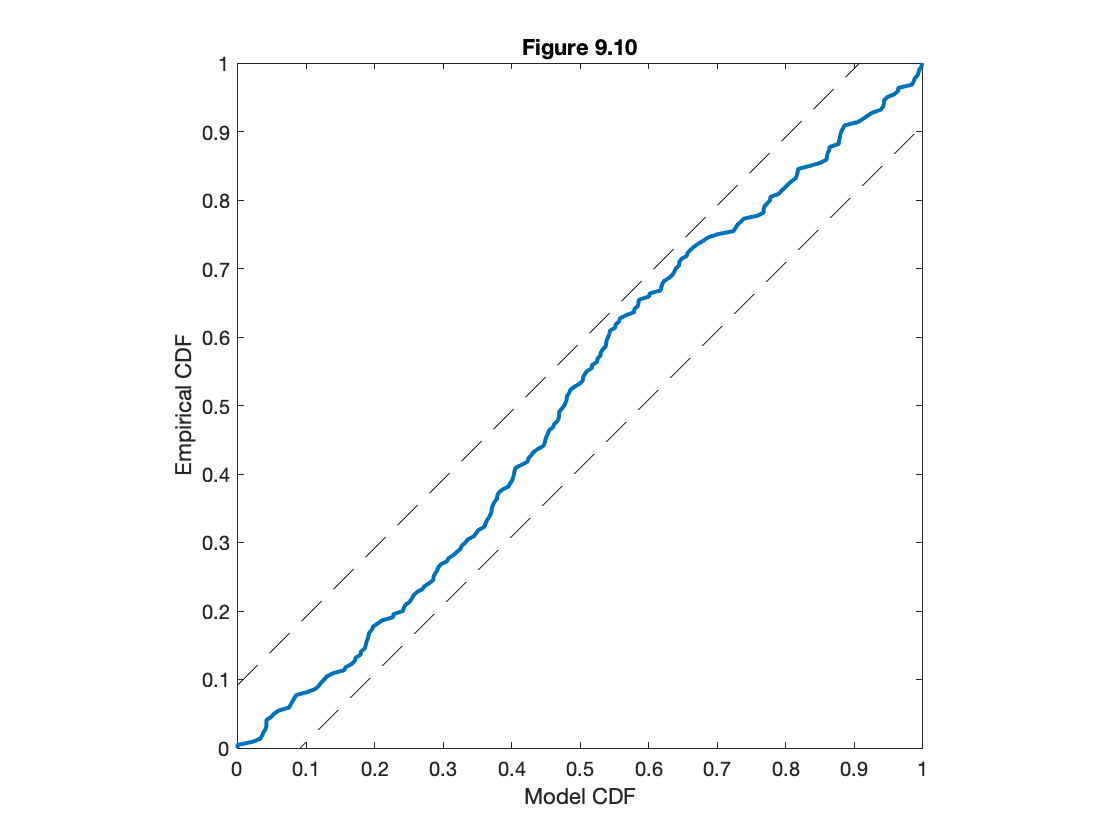

In [44]:
lambda4 = exp(b4(1) + b4(2) * X + b4(3) * X .^ 2 + b4(4) * dir); %Eval. Model 4.
Z = zeros(N, 1); % Initialize rescaled waiting times.
Z(1) = sum(lambda4(1:spikeindex(1))); %1st rescaled waiting time.

for i = 2:N %... and the rest.
    Z(i) = sum(lambda4(spikeindex(i - 1):spikeindex(i)));
end

[eCDF, zvals] = ecdf(Z); %Define empirical CDF,
mCDF = 1 - exp(-zvals); %...and model CDF,

figure
plot(mCDF, eCDF, 'LineWidth', 2) %...to create KS-plot.
hold on %Freeze graphics window.
plot([0 1], [0 1] + 1.36 / sqrt(N), 'k--') %Upper confidence bound.
plot([0 1], [0 1] - 1.36 / sqrt(N), 'k--') %Lower confidence bound.
axis([0 1 0 1]) %Set axis limits.
axis square
xlabel('Model CDF') % Label the axes.
ylabel('Empirical CDF')
title('Figure 9.10') % Title the plot.


### Figure 9.11

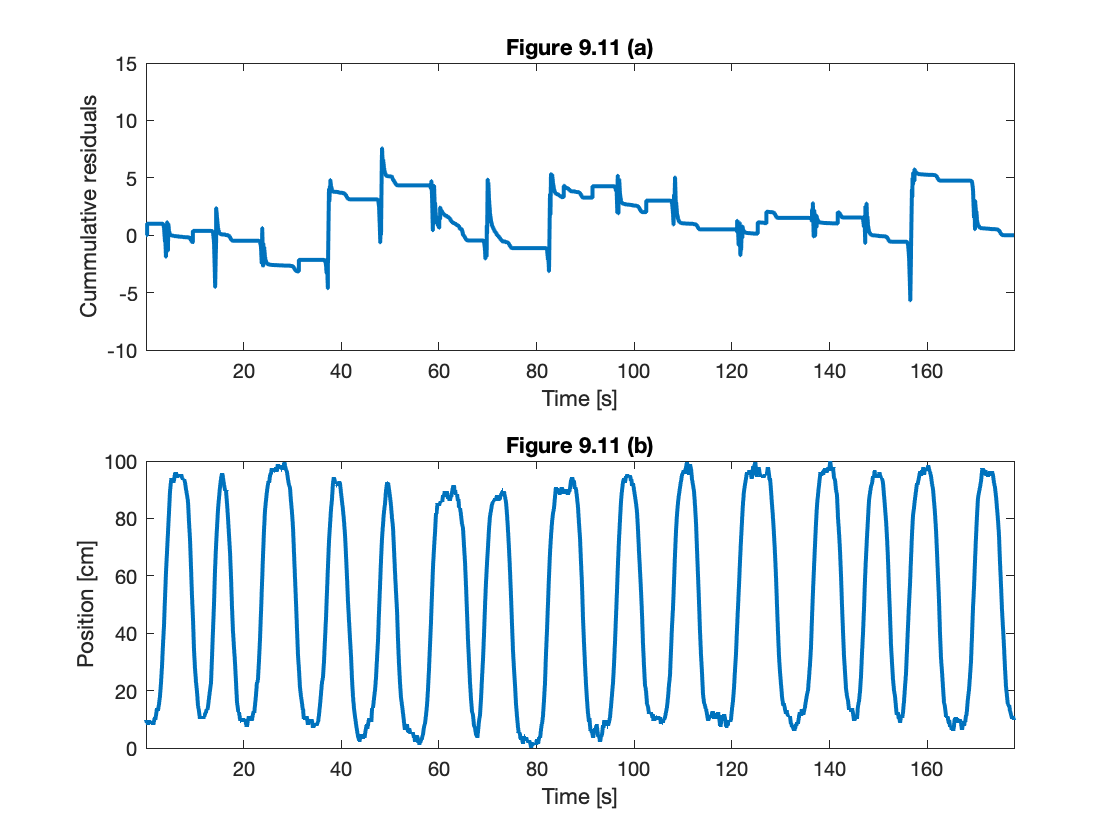

In [47]:
R = cumsum(stats4.resid); %Cumulative sum of Model 4 residuals.

figure
subplot(2, 1, 1)
plot(t, R,'LineWidth', 2) % Plot residuals
xlim tight
ylim([-10, 15])
xlabel('Time [s]') % Label the axes.
ylabel('Cummulative residuals')
title('Figure 9.11 (a)') % Title the plot.

subplot(2, 1, 2)
plot(t, X, 'LineWidth', 2) % Plot position.
xlim tight
ylim([0, 100])
xlabel('Time [s]') % Label the axes.
ylabel('Position [cm]')
title('Figure 9.11 (b)') % Title the plot

## Step 5

In [53]:
% For Model 4, compute maximum likelihood estimates of:
mu = -b4(2) / 2 / b4(3); %...place field center,
sigma = sqrt(-1 / (2 * b4(3))); %...place field size,
alpha = exp(b4(1) - b4(2) ^ 2/4 / b4(3)); %...max firing rate.

fprintf('Center of the place field: mu = %.2f, width: 2*sigma = %.2f\n', mu, 2 * sigma);
fprintf('max firing rate when dir = 0: alpha = %.3f (spikes/s)\n', alpha * 1000);
fprintf('max firing rate when dir = 1: alpha * exp(b4(4)) = %.3f (spikes/s)\n', ...
    alpha * exp(b4(4)) * 1000);


Center of the place field: mu = 63.18, width: 2*sigma = 19.15
max firing rate when dir = 0: alpha = 0.820 (spikes/s)
max firing rate when dir = 1: alpha * exp(b4(4)) = 21.689 (spikes/s)


### Figure 9.12

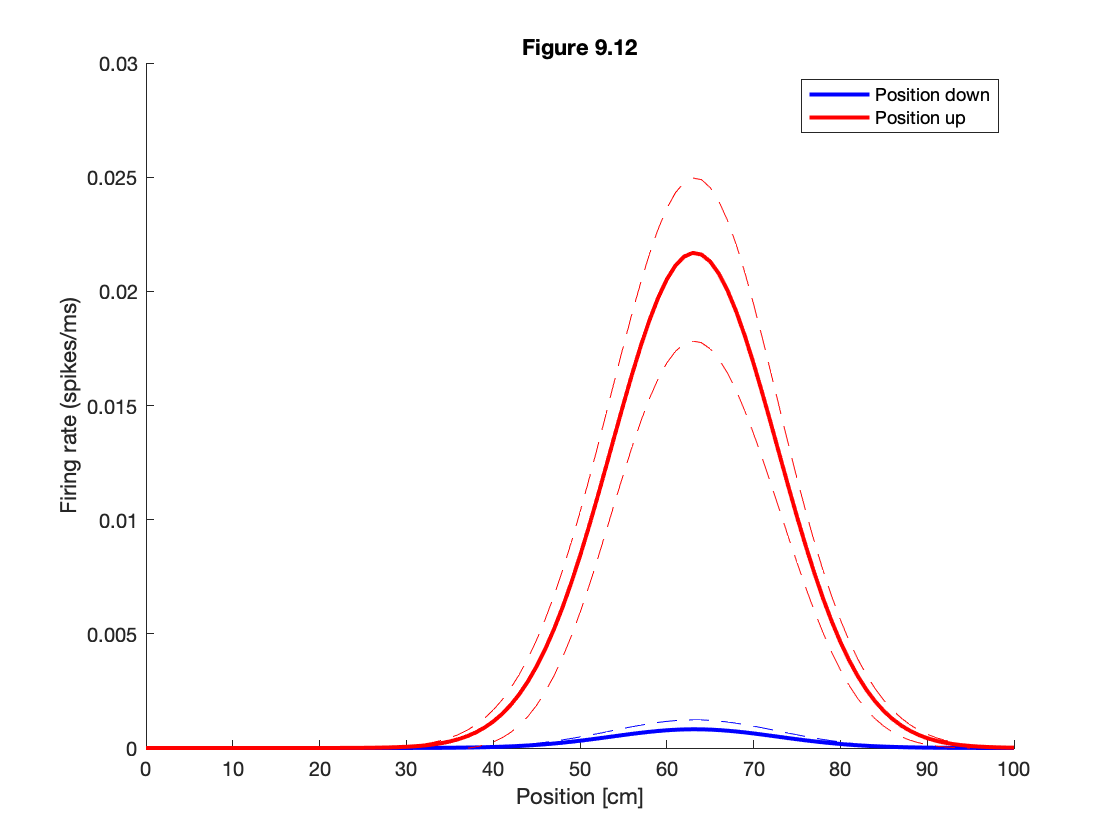

In [57]:
xs = (0:100)'; %Define interval of positions,
Ns = size(xs); %...and number of positions.

% Evaluate Model 4 in direction 0 (X decreases).
[lambda4_0, up0, low0] = glmval(b4, [xs, xs .^ 2, zeros(Ns)], 'log', stats4);
% Evaluate Model 4 in direction 1 (X increases).
[lambda4_1, up1, low1] = glmval(b4, [xs, xs .^ 2, ones(Ns)], 'log', stats4);

figure
hold on %...freeze graphics,
h_d = plot(xs, lambda4_0, 'b', 'LineWidth', 2); %Plot Model 4, X decreasing,
plot(xs, lambda4_0 + up0, 'b--') %...add upper CI,
plot(xs, lambda4_0 - low0, 'b--') %...and lower CI.

h_i = plot(xs, lambda4_1, 'r', 'LineWidth', 2); %Plot Model 4, X increasing,
plot(xs, lambda4_1 + up1, 'r--') %...add upper CI,
plot(xs, lambda4_1 - low1, 'r--'); %...add lower CI.

legend([h_d h_i], {'Position down', 'Position up'})
xlim([0, 100]) %Set x-axis limits.
ylim([0, .03])
xlabel('Position [cm]') % Label the axes.
ylabel('Firing rate (spikes/ms)')
title('Figure 9.12') % Title the plot.
